<a href="https://colab.research.google.com/github/LeonardoVS-dev/Fundamentos/blob/main/graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import numpy as np

dados_eleitorais = pd.read_csv("https://raw.githubusercontent.com/LeonardoVS-dev/Fundamentos/refs/heads/main/dataset/votacao_candidato_munzona_2024_RR%20LIMPADO_CORRIGIDO.csv", encoding="latin-1", sep=";")
dados_flight = pd.read_csv("https://raw.githubusercontent.com/LeonardoVS-dev/Fundamentos/refs/heads/main/dataset/flights.csv", sep=",")

<Axes: xlabel='NM_PARTIDO'>

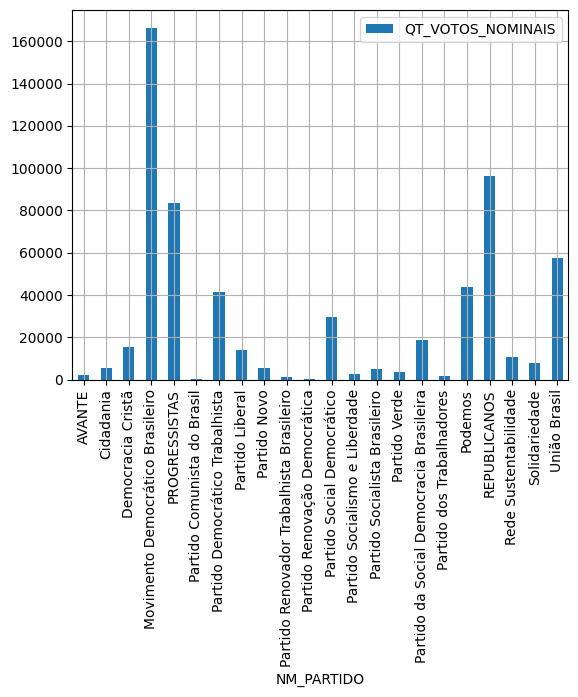

In [55]:
# Gráfico do total de votos por partido

# Faz a cópia do dataframe dados_eleitorais
dados_eleitorais_votos = dados_eleitorais.copy()

# Retira as colunas indesejadas
dados_eleitorais_votos = dados_eleitorais_votos.drop(["NM_MUNICIPIO", "NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO", "CD_CARGO"], axis=1)

# Agrupa pelo nome do partido, somando os valores
dados_eleitorais_votos = dados_eleitorais_votos.groupby(["NM_PARTIDO"]).sum()
#display(dados_eleitorais_votos.plot(kind="bar", grid=True))
dados_eleitorais_votos.plot(kind="bar", grid=True)

<Axes: xlabel='Média de votos por cargo', ylabel='NM_MUNICIPIO,CARGO'>

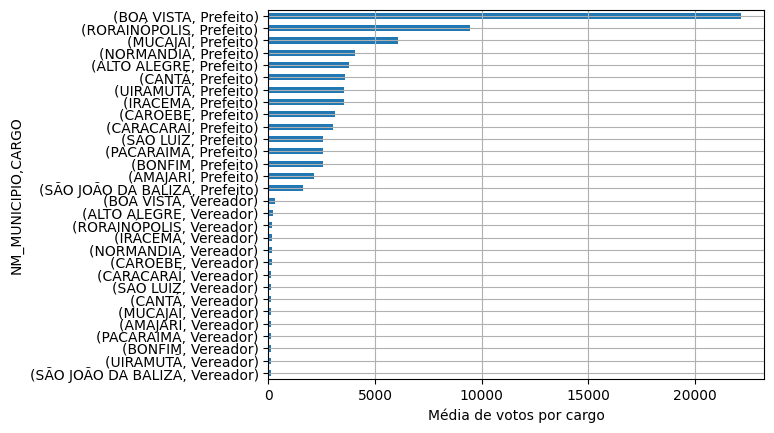

In [56]:
# Gráfico da média de votos por cargo, por município
dados_eleitorais_votos = dados_eleitorais.copy()

# Retira as colunas indesejadas
dados_eleitorais_votos = dados_eleitorais_votos.drop(["NR_ZONA", "NM_CANDIDATO", "NM_URNA_CANDIDATO", "NR_PARTIDO", "SG_PARTIDO", "NM_PARTIDO"], axis=1)

# Aqui, troca faz a troca dos códigos de cargo pelos títulos de cada cargo
dados_eleitorais_votos.loc[dados_eleitorais_votos["CD_CARGO"].isin([13]), "CARGO"] = "Vereador"
dados_eleitorais_votos.loc[dados_eleitorais_votos["CD_CARGO"].isin([11]), "CARGO"] = "Prefeito"

# Agrupa pela cidade e pelo cargo em disputa, retornando a média de votos
dados_eleitorais_votos = dados_eleitorais_votos["QT_VOTOS_NOMINAIS"].groupby([dados_eleitorais_votos['NM_MUNICIPIO'], dados_eleitorais_votos['CARGO']]).mean()

dados_eleitorais_votos.sort_values().plot(kind="barh", grid=True, xlabel="Média de votos por cargo")

<Axes: ylabel='Frequency'>

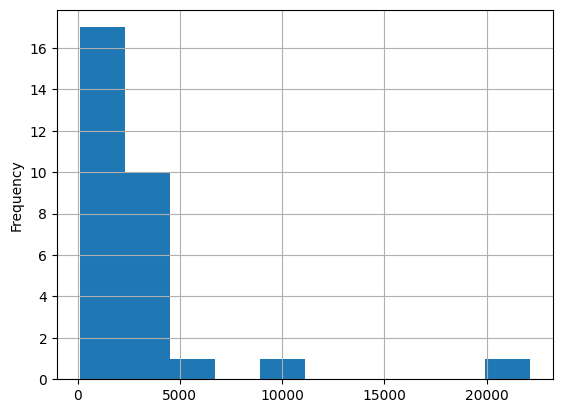

In [49]:
# Mesma ideia do último, mas com um histograma de frequência
# (quantos candidadatos tiveram x votação) no lugar
display(dados_eleitorais_votos.plot(kind="hist", grid=True))

<Axes: xlabel='year', ylabel='passengers/year'>

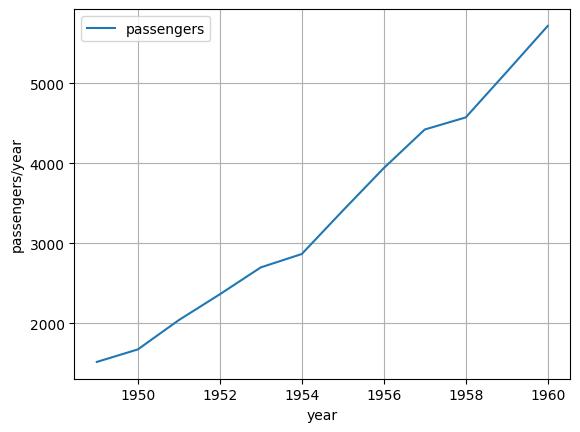

In [53]:
# Gráfico da soma de passageiros por ano

# Remove a coluna "month"
flight_ano = dados_flight.drop(["month"], axis = 1)

# Faz um pivot_table para aplicar a função de soma por ano
flight_ano = flight_ano.pivot_table(index="year", aggfunc="sum")
flight_ano.plot(kind="line", ylabel="passengers/year", grid=True)

<Axes: xlabel='month'>

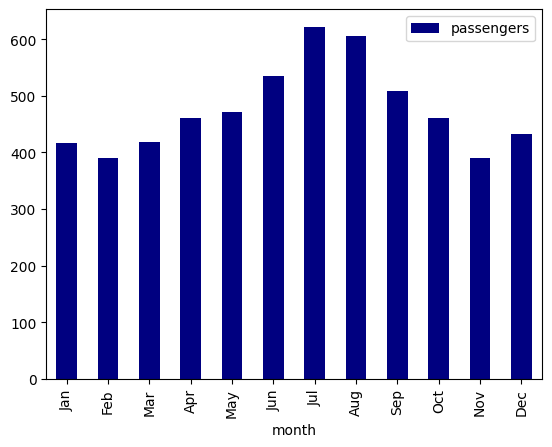

In [88]:
# Gráfico do número de passageiros por mês em 1960
flight_1960 = dados_flight.copy()
# Filtra pelo ano de 1960
flight_1960 = flight_1960[flight_1960['year'] == 1960]
flight_1960.plot(kind="bar", x= "month", y = "passengers", color="navy")